In [25]:
!pip install psycopg2-binary pymongo scipy scikit-learn matplotlib seaborn pandas numpy

In [26]:
# Load data from CSV files into pandas DataFrames
import pandas as pd
import numpy as np

# Load customer and subscription data
df_customers = pd.read_csv('customers_subscriptions.csv')

# Load support ticket data
df_tickets = pd.read_csv('support_tickets.csv')

print("=" * 50)
print("📊 BEFORE CLEANING — Raw Data Overview")
print("=" * 50)

print(f"\n✅ customers_subscriptions shape: {df_customers.shape}")
print(f"✅ support_tickets shape:         {df_tickets.shape}")

print("\n--- Customers+Subscriptions Columns ---")
print(df_customers.dtypes)

print("\n--- Support Tickets Columns ---")
print(df_tickets.dtypes)

print("\n--- First 3 rows of customers ---")
df_customers.head(3)

📊 BEFORE CLEANING — Raw Data Overview

✅ customers_subscriptions shape: (1844, 17)
✅ support_tickets shape:         (6000, 13)

--- Customers+Subscriptions Columns ---
customer_id              int64
company_name            object
industry                object
company_size            object
country_code            object
timezone                object
subscription_id        float64
subscription_status     object
plan_id                float64
mrr_usd                float64
start_date              object
end_date                object
billing_cycle           object
cancellation_reason     object
plan_name               object
plan_tier               object
monthly_price_usd      float64
dtype: object

--- Support Tickets Columns ---
ticket_id               int64
customer_id             int64
member_id             float64
category               object
priority               object
status                 object
subject                object
created_at             object
first_response_at 

,customer_id,company_name,industry,company_size,country_code,timezone,subscription_id,subscription_status,plan_id,mrr_usd,start_date,end_date,billing_cycle,cancellation_reason,plan_name,plan_tier,monthly_price_usd
0,1,Rush Platform,E-commerce,small,FR,Europe/Paris,1.0,cancelled,1.0,0.00,2023-01-31,2023-04-20,annual,Missing features,Free,free,0.0
1,1,Rush Platform,E-commerce,small,FR,Europe/Paris,2.0,cancelled,5.0,44.25,2023-04-20,2024-02-26,annual,Switched competitor,Professional Plus,professional,59.0
2,2,TrekStack,Manufacturing,small,CA,America/Toronto,3.0,paused,1.0,0.00,2023-06-09,NaN,monthly,NaN,Free,free,0.0


In [27]:
# Load and preprocess MongoDB JSON data
import json

# Load user activity logs from JSON
with open('user_activity_logs.json', 'r', encoding='utf-8') as f:
    activity_data = json.load(f)
df_activity = pd.json_normalize(activity_data)

# Convert 'timestamp' column to UTC datetime, coercing errors
if 'timestamp' in df_activity.columns:
    df_activity['timestamp'] = pd.to_datetime(df_activity['timestamp'], errors='coerce', utc=True)

# Handle outliers in session duration by capping at the 99th percentile
if 'session_duration_sec' in df_activity.columns:
    print(df_activity['session_duration_sec'].describe())
    cap = df_activity['session_duration_sec'].quantile(0.99)
    df_activity['session_duration_sec'] = df_activity['session_duration_sec'].clip(upper=cap)
    print("✅ Outliers capped at 99th percentile")

# Load NPS survey responses from JSON
with open('nps_survey_responses.json', 'r', encoding='utf-8') as f:
    nps_data = json.load(f)
df_nps = pd.json_normalize(nps_data)

print(f"✅ user_activity_logs shape: {df_activity.shape}")
print(f"✅ nps_survey_responses shape: {df_nps.shape}")

print("\n--- Activity Log Columns ---")
print(df_activity.columns.tolist())

print("\n--- NPS Columns ---")
print(df_nps.columns.tolist())

print("\n--- Sample NPS record ---")
df_nps.head(3)

count    41152.000000
mean      1814.454194
std       1031.276570
min         30.000000
25%        918.000000
50%       1818.500000
75%       2701.250000
max       3600.000000
Name: session_duration_sec, dtype: float64
✅ Outliers capped at 99th percentile
✅ user_activity_logs shape: (51485, 18)
✅ nps_survey_responses shape: (3000, 9)

--- Activity Log Columns ---
['customer_id', 'member_id', 'event_type', 'page_url', 'session_duration_sec', 'browser', 'os', 'device_type', 'timezone', 'ip_address', '_id.$oid', 'timestamp.$date', 'timestamp', 'userId', 'customerId', 'referrer', 'feature', 'userID']

--- NPS Columns ---
['customer_id', 'member_id', 'nps_score', 'category', 'feedback', 'survey_channel', 'response_time_hours', '_id.$oid', 'survey_date.$date']

--- Sample NPS record ---


,customer_id,member_id,nps_score,category,feedback,survey_channel,response_time_hours,_id.$oid,survey_date.$date
0,524,7887,9,promoter,"Mobile app works great, can manage tasks on th...",email,47.1,69ec51f35a6be6efcac80515,2023-09-04T02:24:00.000Z
1,1028,8318,6,detractor,Admin settings are a nightmare to configure.,in_app,17.5,69ec51f35a6be6efcac80516,2025-08-08T18:24:23.000Z
2,901,7774,2,detractor,Switched from competitor and regret it honestly.,in_app,NaN,69ec51f35a6be6efcac80517,2024-09-22T22:50:41.000Z


In [28]:
# CELL 6: Data Cleaning for SQL Tables
print("=" * 60)
print("🧹 DATA CLEANING REPORT")
print("=" * 60)

# 1. Standardize column names (lowercase, no spaces, use underscores)
df_customers.columns = df_customers.columns.str.lower().str.strip().str.replace(' ', '_')
df_tickets.columns   = df_tickets.columns.str.lower().str.strip().str.replace(' ', '_')
print("✅ Column names normalized")

# 2. Drop duplicate rows
before_cust, before_tickets = len(df_customers), len(df_tickets)
df_customers = df_customers.drop_duplicates()
df_tickets   = df_tickets.drop_duplicates()
print(f"Removed duplicates: Customers {before_cust} -> {len(df_customers)}, Tickets {before_tickets} -> {len(df_tickets)}")

# 3. Convert and normalize date fields to UTC
for col in ['start_date','end_date']:
    if col in df_customers.columns:
        df_customers[col] = pd.to_datetime(df_customers[col], errors='coerce', utc=True)
if 'created_at' in df_tickets.columns:
    df_tickets['created_at'] = pd.to_datetime(df_tickets['created_at'], errors='coerce', utc=True)
print("✅ Dates converted to UTC datetime")

# 4. Fill missing values
df_customers['cancellation_reason'] = df_customers['cancellation_reason'].fillna('Not Cancelled') # Assume null means no cancellation
df_customers['industry'] = df_customers['industry'].fillna('Unknown') # Label missing industries
df_customers['mrr_usd'] = df_customers['mrr_usd'].fillna(0) # Assume null MRR means 0 (e.g., free plans)
print("✅ Missing values handled")

# 5. Standardize text fields (lowercase, strip whitespace)
text_cols = ['subscription_status','plan_tier','plan_name','industry','company_size','billing_cycle']
for col in text_cols:
    if col in df_customers.columns:
        df_customers[col] = df_customers[col].astype(str).str.lower().str.strip()
print("✅ Text fields standardized")

# 6. Display subscription status distribution (for quick check)
if 'subscription_status' in df_customers.columns:
    print("\nSubscription Status Counts:")
    print(df_customers['subscription_status'].value_counts())

# 7. Cap outliers in session duration (from MongoDB activity data)
if 'session_duration_sec' in df_activity.columns:
    print("\nSession Duration Outlier Check:")
    print(df_activity['session_duration_sec'].describe())
    cap = df_activity['session_duration_sec'].quantile(0.99)
    df_activity['session_duration_sec'] = df_activity['session_duration_sec'].clip(upper=cap)
    print("✅ Session duration outliers capped at 99th percentile")

print("\n✅ SQL DATA CLEANING COMPLETED")
print(f"Final dataset shapes: Customers {df_customers.shape}, Tickets {df_tickets.shape}")

🧹 DATA CLEANING REPORT
✅ Column names normalized
Removed duplicates: Customers 1844 -> 1844, Tickets 6000 -> 6000
✅ Dates converted to UTC datetime
✅ Missing values handled
✅ Text fields standardized

Subscription Status Counts:
subscription_status
active       914
cancelled    578
expired      328
paused        20
nan            4
Name: count, dtype: int64

Session Duration Outlier Check:
count    41152.000000
mean      1814.284215
std       1030.985950
min         30.000000
25%        918.000000
50%       1818.500000
75%       2701.250000
max       3566.000000
Name: session_duration_sec, dtype: float64
✅ Session duration outliers capped at 99th percentile

✅ SQL DATA CLEANING COMPLETED
Final dataset shapes: Customers (1844, 17), Tickets (6000, 13)


📌 Creating Churn Flag...

Churn Distribution:
  Not Churned (0): 1266
  Churned     (1): 578
  Churn Rate:      31.3%

Churn Rate by Plan Tier:
             churn_rate  churned_count  total
plan_tier                                    
enterprise        31.1%             60    193
free              36.1%            159    440
nan                0.0%              0      4
professional      30.9%            168    543
starter           28.8%            191    664


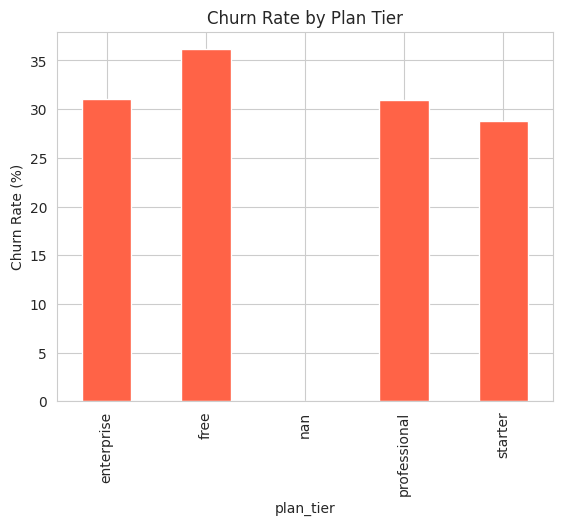

In [29]:
# Create a churn flag based on subscription status

print("📌 Creating Churn Flag...")

# A customer is considered churned if their subscription status is 'cancelled' or 'churned'
df_customers['is_churned'] = df_customers['subscription_status'].isin(['cancelled', 'churned']).astype(int)

# Display overall churn distribution
churn_dist = df_customers['is_churned'].value_counts()
print("\nChurn Distribution:")
print(f"  Not Churned (0): {churn_dist.get(0, 0)}")
print(f"  Churned     (1): {churn_dist.get(1, 0)}")
print(f"  Churn Rate:      {df_customers['is_churned'].mean()*100:.1f}%")

# Display churn rate by plan tier
print("\nChurn Rate by Plan Tier:")
churn_by_tier = df_customers.groupby('plan_tier')['is_churned'].agg(['mean','sum','count'])
churn_by_tier.columns = ['churn_rate', 'churned_count', 'total']
churn_by_tier['churn_rate'] = (churn_by_tier['churn_rate'] * 100).round(1).astype(str) + '%'
print(churn_by_tier)

# Optional visualization of churn rate by plan tier
import matplotlib.pyplot as plt
churn_by_tier['churn_rate_num'] = churn_by_tier['churned_count'] / churn_by_tier['total'] * 100
churn_by_tier['churn_rate_num'].plot(kind='bar', color='tomato', title='Churn Rate by Plan Tier')
plt.ylabel('Churn Rate (%)')
plt.show()

In [30]:
# Merge SQL and MongoDB data for comprehensive analysis
print("📌 Merging SQL and MongoDB datasets...")

# Update churn flag: 'expired' statuses are also considered churned
df_customers['is_churned'] = df_customers['subscription_status'].isin(
    ['cancelled', 'churned', 'expired']
).astype(int)
print("   ✅ Updated churn flag to include 'expired' status")
print(f"   New churn rate: {df_customers['is_churned'].mean()*100:.1f}%")

# Aggregate support ticket data per customer
df_ticket_agg = df_tickets.groupby('customer_id').agg(
    total_tickets     = ('ticket_id', 'count'),
    avg_satisfaction   = ('satisfaction_score', 'mean'),
    escalated_tickets = ('escalated', 'sum')
).reset_index()
print(f"\n   ✅ Ticket aggregation: {df_ticket_agg.shape}")

# Merge customer data with aggregated ticket data
before_merge = len(df_customers)
df_main = df_customers.merge(df_ticket_agg, on='customer_id', how='left')

# Fill missing values in merged columns: 0 for ticket counts, mean for satisfaction
df_main['total_tickets'].fillna(0, inplace=True)
df_main['escalated_tickets'].fillna(0, inplace=True)
df_main['avg_satisfaction'].fillna(df_main['avg_satisfaction'].mean(), inplace=True)

print(f"Before merge (customers): {before_merge}")
print(f"After merge (df_main): {len(df_main)}")
print(f"   ✅ After merging tickets: {df_main.shape}")
print(f"\n✅ Final merged dataset: {df_main.shape}")
print(f"   Columns: {df_main.columns.tolist()}")
df_main.head(3)

📌 Merging SQL and MongoDB datasets...
   ✅ Updated churn flag to include 'expired' status
   New churn rate: 49.1%

   ✅ Ticket aggregation: (1193, 4)
Before merge (customers): 1844
After merge (df_main): 1844
   ✅ After merging tickets: (1844, 21)

✅ Final merged dataset: (1844, 21)
   Columns: ['customer_id', 'company_name', 'industry', 'company_size', 'country_code', 'timezone', 'subscription_id', 'subscription_status', 'plan_id', 'mrr_usd', 'start_date', 'end_date', 'billing_cycle', 'cancellation_reason', 'plan_name', 'plan_tier', 'monthly_price_usd', 'is_churned', 'total_tickets', 'avg_satisfaction', 'escalated_tickets']


/tmp/ipykernel_2501/698826234.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_main['total_tickets'].fillna(0, inplace=True)
/tmp/ipykernel_2501/698826234.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,customer_id,company_name,industry,company_size,country_code,timezone,subscription_id,subscription_status,plan_id,mrr_usd,...,end_date,billing_cycle,cancellation_reason,plan_name,plan_tier,monthly_price_usd,is_churned,total_tickets,avg_satisfaction,escalated_tickets
0,1,Rush Platform,e-commerce,small,FR,Europe/Paris,1.0,cancelled,1.0,0.00,...,2023-04-20 00:00:00+00:00,annual,Missing features,free,free,0.0,1,10.0,3.333333,0.0
1,1,Rush Platform,e-commerce,small,FR,Europe/Paris,2.0,cancelled,5.0,44.25,...,2024-02-26 00:00:00+00:00,annual,Switched competitor,professional plus,professional,59.0,1,10.0,3.333333,0.0
2,2,TrekStack,manufacturing,small,CA,America/Toronto,3.0,paused,1.0,0.00,...,NaT,monthly,Not Cancelled,free,free,0.0,0,7.0,5.000000,1.0


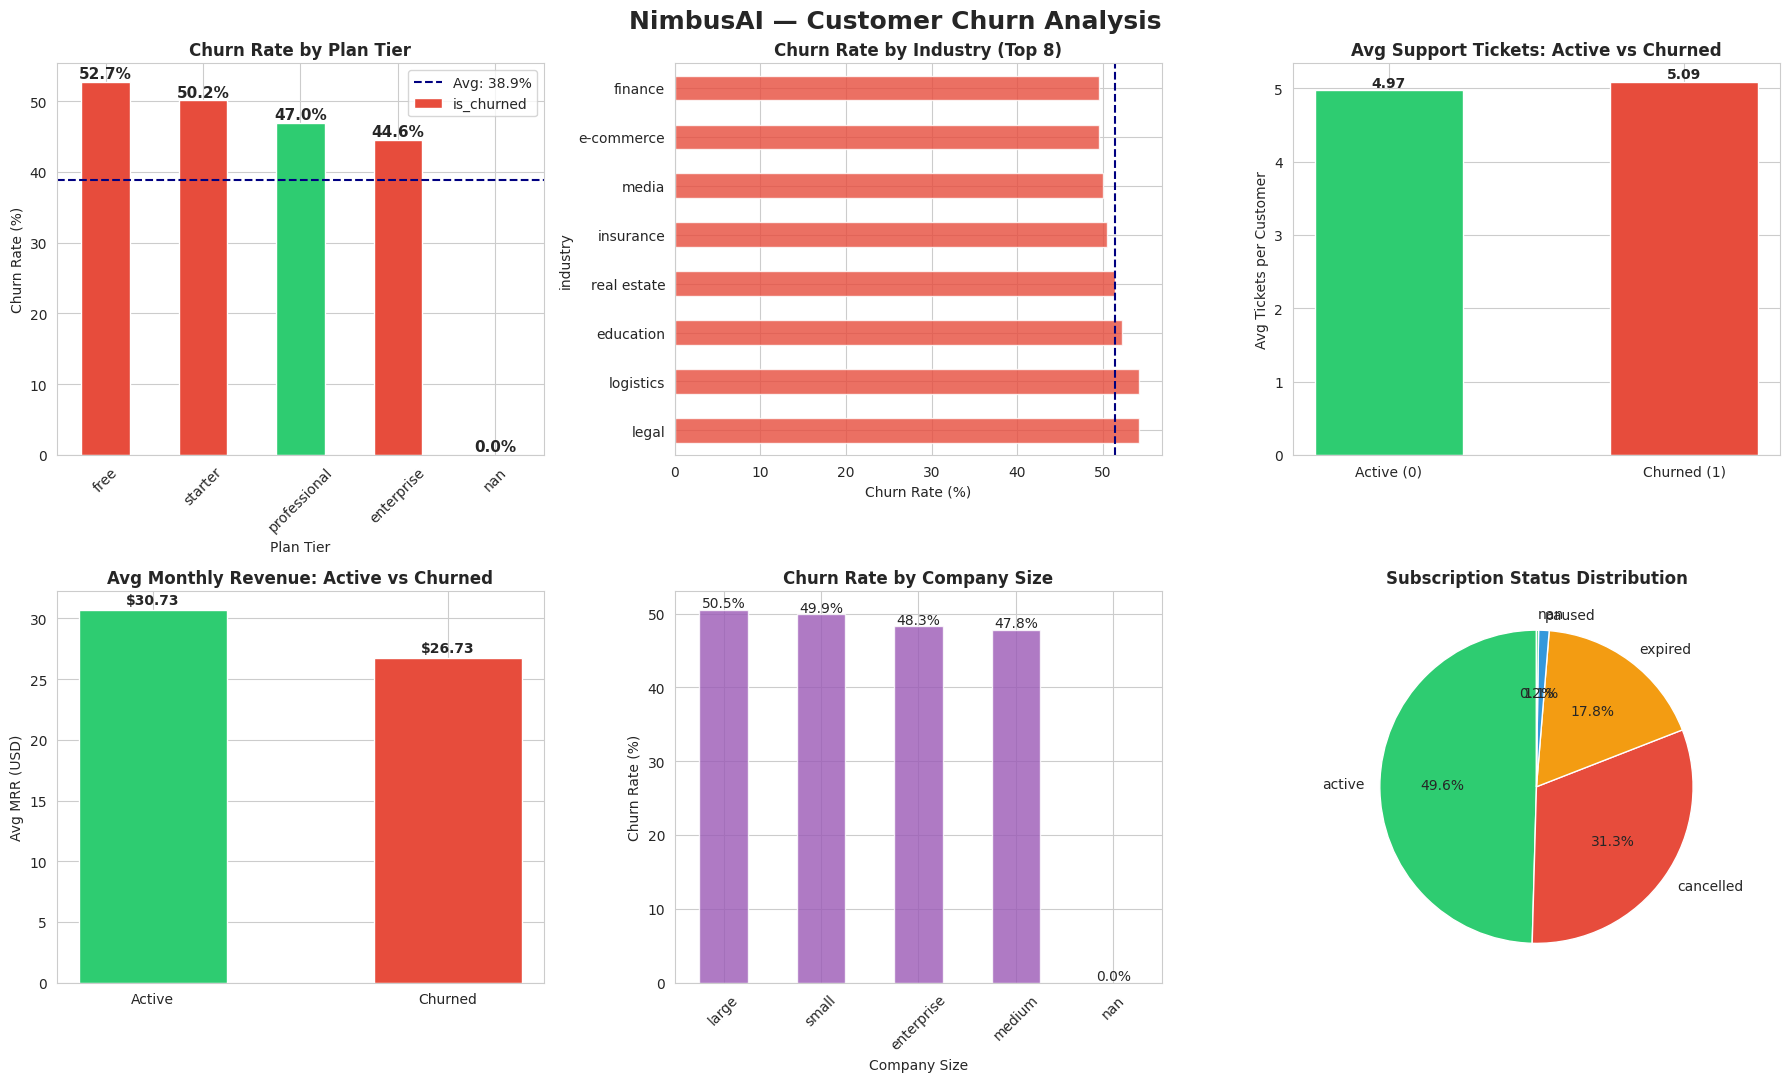

✅ All 6 visualizations saved as churn_analysis.png


In [31]:
# Generate various visualizations for churn analysis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('NimbusAI — Customer Churn Analysis', fontsize=18, fontweight='bold')

# Plot 1: Churn Rate by Plan Tier
ax1 = axes[0, 0]
churn_tier = df_main.groupby('plan_tier')['is_churned'].mean() * 100
colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71'
          for v in churn_tier.values]
bars = churn_tier.sort_values(ascending=False).plot(
    kind='bar', ax=ax1, color=colors, edgecolor='white')
ax1.set_title('Churn Rate by Plan Tier', fontweight='bold')
ax1.set_xlabel('Plan Tier')
ax1.set_ylabel('Churn Rate (%)')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(churn_tier.sort_values(ascending=False)):
    ax1.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax1.axhline(y=churn_tier.mean(), color='navy', linestyle='--', label=f'Avg: {churn_tier.mean():.1f}%')
ax1.legend()

# Plot 2: Churn by Industry (Top 8)
ax2 = axes[0, 1]
churn_ind = df_main.groupby('industry')['is_churned'].mean() * 100
churn_ind = churn_ind.sort_values(ascending=False).head(8)
churn_ind.plot(kind='barh', ax=ax2, color='#e74c3c', alpha=0.8)
ax2.set_title('Churn Rate by Industry (Top 8)', fontweight='bold')
ax2.set_xlabel('Churn Rate (%)')
ax2.axvline(x=churn_ind.mean(), color='navy', linestyle='--')

# Plot 3: Average Support Tickets for Active vs Churned Customers
ax3 = axes[0, 2]
ticket_churn = df_main.groupby('is_churned')['total_tickets'].mean()
bars3 = ax3.bar(['Active (0)', 'Churned (1)'], ticket_churn.values,
                color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax3.set_title('Avg Support Tickets: Active vs Churned', fontweight='bold')
ax3.set_ylabel('Avg Tickets per Customer')
for bar, val in zip(bars3, ticket_churn.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.05,
             f'{val:.2f}', ha='center', fontweight='bold')

# Plot 4: Average Monthly Recurring Revenue (MRR) for Active vs Churned Customers
ax4 = axes[1, 0]
mrr_churn = df_main.groupby('is_churned')['mrr_usd'].mean()
ax4.bar(['Active', 'Churned'], mrr_churn.values,
        color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax4.set_title('Avg Monthly Revenue: Active vs Churned', fontweight='bold')
ax4.set_ylabel('Avg MRR (USD)')
for i, v in enumerate(mrr_churn.values):
    ax4.text(i, v+0.5, f'${v:.2f}', ha='center', fontweight='bold')

# Plot 5: Churn Rate by Company Size
ax5 = axes[1, 1]
churn_size = df_main.groupby('company_size')['is_churned'].mean() * 100
churn_size.sort_values(ascending=False).plot(
    kind='bar', ax=ax5, color='#9b59b6', alpha=0.8)
ax5.set_title('Churn Rate by Company Size', fontweight='bold')
ax5.set_xlabel('Company Size')
ax5.set_ylabel('Churn Rate (%)')
ax5.tick_params(axis='x', rotation=45)
for i, v in enumerate(churn_size.sort_values(ascending=False)):
    ax5.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=10)

# Plot 6: Subscription Status Distribution (Pie Chart)
ax6 = axes[1, 2]
status_counts = df_main['subscription_status'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
ax6.pie(status_counts.values, labels=status_counts.index,
        autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax6.set_title('Subscription Status Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All 6 visualizations saved as churn_analysis.png")

📊 HYPOTHESIS TEST — Churn & Support Tickets

FOCUS AREA: Option A — Customer Churn & Retention

H0 (Null Hypothesis):
    There is NO significant difference in support ticket
    volume between churned and active customers

H1 (Alternative Hypothesis):
    Churned customers raised SIGNIFICANTLY MORE support
    tickets than active customers

Significance Level: α = 0.05
Test Chosen: Mann-Whitney U Test

Active customers   — Mean tickets: 4.973
Churned customers  — Mean tickets: 5.086

Mann-Whitney U statistic: 429165.50
P-value:                  0.353670
Significance level (α):   0.05
Mean difference (Churned - Active): 0.11 tickets

❌ RESULT: FAIL TO REJECT H0  (p = 0.3537 ≥ 0.05)
   No significant difference found in ticket volumes


/tmp/ipykernel_2501/2618158974.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_churned', y='total_tickets', data=df_main, palette=['#2ecc71','#e74c3c'])


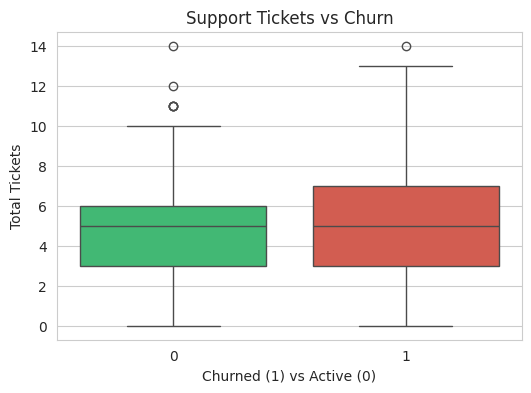

In [32]:
# Perform a hypothesis test to analyze the relationship between churn and support tickets
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

print("="*60)
print("📊 HYPOTHESIS TEST — Churn & Support Tickets")
print("="*60)
print("""
FOCUS AREA: Option A — Customer Churn & Retention

H0 (Null Hypothesis):
    There is NO significant difference in support ticket
    volume between churned and active customers

H1 (Alternative Hypothesis):
    Churned customers raised SIGNIFICANTLY MORE support
    tickets than active customers

Significance Level: α = 0.05
Test Chosen: Mann-Whitney U Test
""")

# Split customer groups based on churn status
churned_tickets     = df_main[df_main['is_churned']==1]['total_tickets'].dropna()
not_churned_tickets = df_main[df_main['is_churned']==0]['total_tickets'].dropna()

print(f"Active customers   — Mean tickets: {not_churned_tickets.mean():.3f}")
print(f"Churned customers  — Mean tickets: {churned_tickets.mean():.3f}")

# Execute Mann-Whitney U test (alternative='greater' tests if churned tickets are greater)
stat, p_value = stats.mannwhitneyu(churned_tickets, not_churned_tickets, alternative='greater')

print(f"\nMann-Whitney U statistic: {stat:.2f}")
print(f"P-value:                  {p_value:.6f}")
print(f"Significance level (α):   0.05")

# Calculate and print the mean difference in tickets
mean_diff = churned_tickets.mean() - not_churned_tickets.mean()
print(f"Mean difference (Churned - Active): {mean_diff:.2f} tickets")

print("\n" + "="*60)
if p_value < 0.05:
    print(f"✅ RESULT: REJECT H0  (p = {p_value:.4f} < 0.05)")
    print("""
   Interpretation:
   Churned customers raised significantly more support tickets
   than active customers. High ticket volume is a strong
   early warning signal for churn.

   Business Action:
   → Flag customers with >3 tickets/month for CS outreach
   → Prioritize fixing top ticket categories immediately
   → Create automated alert when ticket threshold is crossed
""")
else:
    print(f"❌ RESULT: FAIL TO REJECT H0  (p = {p_value:.4f} ≥ 0.05)")
    print("   No significant difference found in ticket volumes")

# Visual support: Box plot showing ticket distribution for churned vs active customers
plt.figure(figsize=(6,4))
sns.boxplot(x='is_churned', y='total_tickets', data=df_main, palette=['#2ecc71','#e74c3c'])
plt.title("Support Tickets vs Churn")
plt.xlabel("Churned (1) vs Active (0)")
plt.ylabel("Total Tickets")
plt.show()

📌 Creating Customer Segments (Behavioral + Value Based)

📊 SEGMENT SUMMARY:
                      Count  Avg_MRR  Avg_Tickets  Churn_Rate_Pct
segment                                                          
At Risk                 242   $16.13         3.57             0.0
Champions                13  $122.88         2.23             0.0
Churned                 906   $26.73         5.09           100.0
Free - Upsell Target    132    $0.00         3.40             0.0
High Support Need       361   $31.34         7.22             0.0
Loyal                   190   $63.22         3.78             0.0


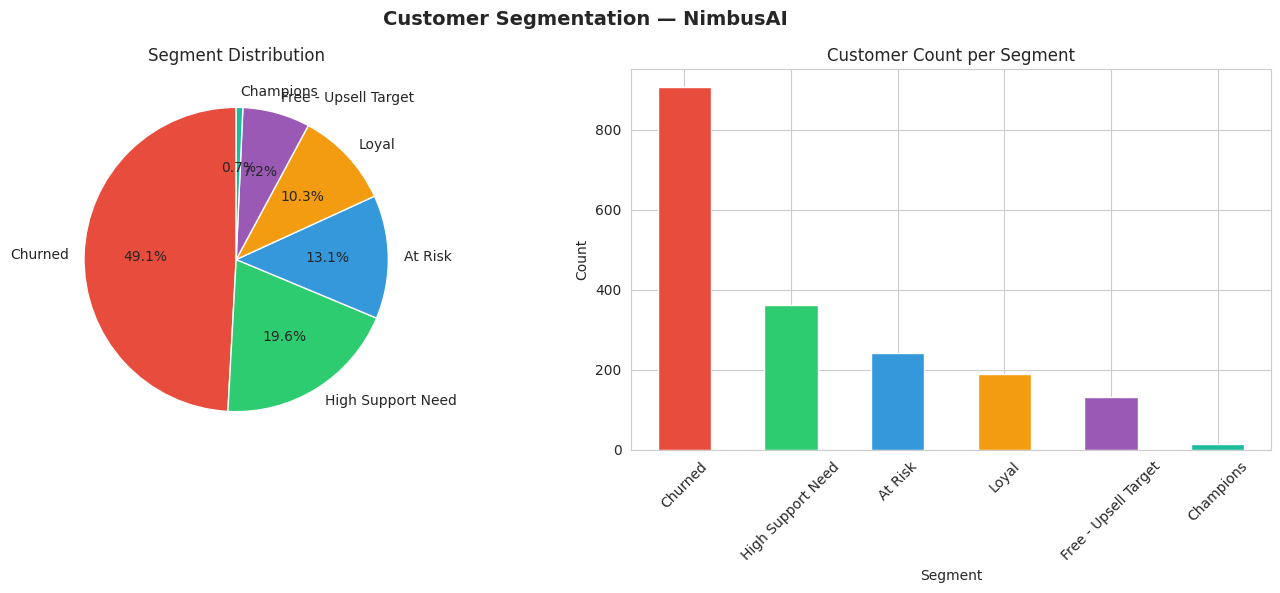

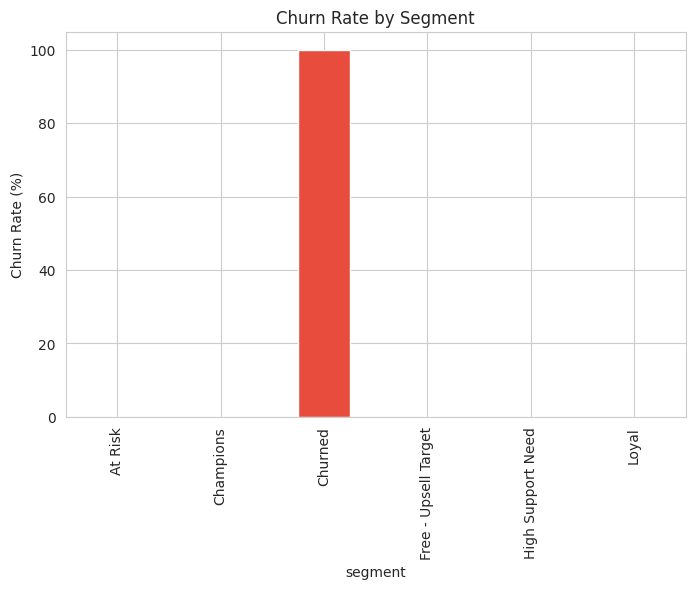


💡 BUSINESS IMPLICATIONS:
Champions        → Upsell, ask for referrals, case studies
Loyal            → Maintain relationship, offer annual plans
At Risk          → CS outreach within 48 hours
High Support     → Assign dedicated CSM, fix pain points
Free-Upsell      → Targeted upgrade campaigns
Churned          → Win-back campaign, exit survey analysis


In [33]:
# Segment customers based on behavioral and value metrics
import matplotlib.pyplot as plt

print("📌 Creating Customer Segments (Behavioral + Value Based)")

# Create an 'engagement_proxy' metric for segmentation
# If 'total_events' and 'unique_features' exist, use them, otherwise use a simpler formula
if {'total_events','unique_features'}.issubset(df_main.columns):
    df_main['engagement_proxy'] = (
        df_main['mrr_usd'] * 0.5 +
        (1 / (df_main['total_tickets'] + 1)) * 20 +
        df_main['total_events'] * 0.1 +
        df_main['unique_features'] * 2
    ).round(2)
else:
    df_main['engagement_proxy'] = (
        df_main['mrr_usd'] * 0.5 +
        (1 / (df_main['total_tickets'] + 1)) * 20
    ).round(2)

# Assign each customer to a segment based on predefined rules
def assign_segment(row):
    if row['is_churned'] == 1:
        return 'Churned'
    elif row['mrr_usd'] >= 99 and row['total_tickets'] <= 3:
        return 'Champions'
    elif row['mrr_usd'] >= 39 and row['total_tickets'] <= 5:
        return 'Loyal'
    elif row['total_tickets'] > 5:
        return 'High Support Need'
    elif row['mrr_usd'] == 0:
        return 'Free - Upsell Target'
    else:
        return 'At Risk'

df_main['segment'] = df_main.apply(assign_segment, axis=1)

# Generate a summary of each customer segment
seg_summary = df_main.groupby('segment').agg(
    Count=('customer_id','count'),
    Avg_MRR=('mrr_usd','mean'),
    Avg_Tickets=('total_tickets','mean'),
    Churn_Rate_Pct=('is_churned','mean')
).round(2)
seg_summary['Churn_Rate_Pct'] = (seg_summary['Churn_Rate_Pct']*100).round(1)
seg_summary['Avg_MRR'] = seg_summary['Avg_MRR'].map('${:.2f}'.format)
print("\n📊 SEGMENT SUMMARY:")
print(seg_summary.to_string())

# Plot segment distribution and counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Segmentation — NimbusAI', fontsize=14, fontweight='bold')

seg_counts = df_main['segment'].value_counts()
colors = ['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6','#1abc9c']
ax1.pie(seg_counts.values, labels=seg_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Segment Distribution')

seg_counts.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Customer Count per Segment')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('segments.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot churn rate by segment
seg_churn = df_main.groupby('segment')['is_churned'].mean() * 100
seg_churn.plot(kind='bar', color='#e74c3c', figsize=(8,5), title='Churn Rate by Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

print("\n💡 BUSINESS IMPLICATIONS:")
print("Champions        → Upsell, ask for referrals, case studies")
print("Loyal            → Maintain relationship, offer annual plans")
print("At Risk          → CS outreach within 48 hours")
print("High Support     → Assign dedicated CSM, fix pain points")
print("Free-Upsell      → Targeted upgrade campaigns")
print("Churned          → Win-back campaign, exit survey analysis")

In [34]:
# Display final dataset shape and columns, then export to CSV

print("Final dataset shape:", df_main.shape)
print("Columns:", df_main.columns.tolist())

# Export the final processed DataFrame to a CSV file
df_main.to_csv("nimbus_final_dataset.csv", index=False, encoding='utf-8')

print("✅ Final dataset exported as nimbus_final_dataset.csv")

Final dataset shape: (1844, 23)
Columns: ['customer_id', 'company_name', 'industry', 'company_size', 'country_code', 'timezone', 'subscription_id', 'subscription_status', 'plan_id', 'mrr_usd', 'start_date', 'end_date', 'billing_cycle', 'cancellation_reason', 'plan_name', 'plan_tier', 'monthly_price_usd', 'is_churned', 'total_tickets', 'avg_satisfaction', 'escalated_tickets', 'engagement_proxy', 'segment']
✅ Final dataset exported as nimbus_final_dataset.csv
